# Statmorph Non-Parametric Morphology Analysis

Run statmorph on all 23 FRB host galaxies to get non-parametric morphological
measurements (CAS, Gini-M20, etc.) and compare Sersic fit results against GALFIT.

In [5]:
import os
import numpy as np
import pandas as pd
import statmorph
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.convolution import convolve, Gaussian2DKernel
from photutils.segmentation import detect_threshold, detect_sources
from photutils.background import Background2D, MedianBackground
%matplotlib inline

In [6]:
# Load FRB coordinates (contains crop regions) and GALFIT results for comparison
coords = pd.read_csv('master_frb_summary.csv')
galfit = pd.read_csv('galfit_inc_angle.csv')

galaxy_dir = 'cropped_host_galaxies'
galaxy_files = sorted([f for f in os.listdir(galaxy_dir) if f.endswith('_flux.fits')])
frb_names = [f.replace('_flux.fits', '') for f in galaxy_files]

print(f'Found {len(frb_names)} galaxies')
print(f'GALFIT results for {len(galfit)} galaxies')

Found 23 galaxies
GALFIT results for 23 galaxies



Processing 20171020A
  Image shape: (146, 146)
  Background: mean=159.947451, median=110.363312, std=217.833707
  Segmap: 1 sources, central label=1, central source pixels=4901
  Non-parametric: Gini=0.4196, M20=-1.2022, C=2.1590, A=-0.0256, S=0.0018
  Sersic: n=0.4479, Re=40.09px, ellip=0.6036, q=0.3964, inc=66.65°, chi2/dof=53660218486125.6797


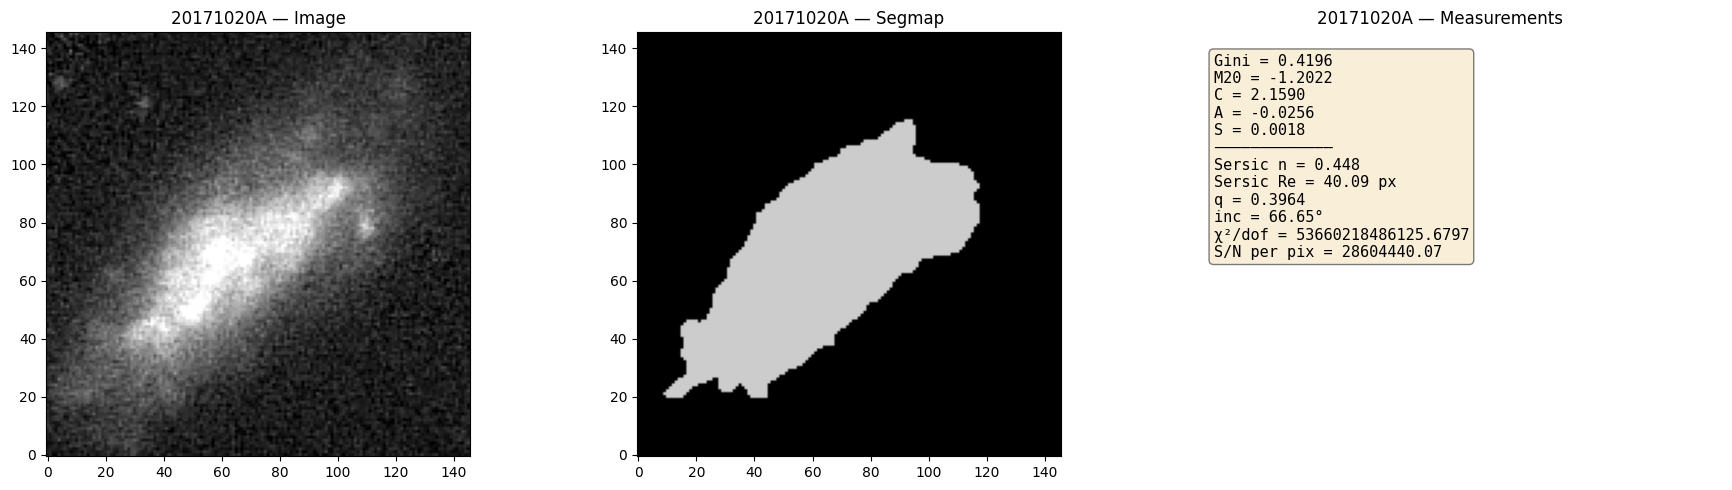


Processing 20180924B
  Image shape: (57, 57)
  Background: mean=0.000659, median=0.000547, std=0.001995
  Segmap: 1 sources, central label=1, central source pixels=379
  Non-parametric: Gini=0.5305, M20=-1.7226, C=2.8335, A=0.0059, S=0.0571
  Sersic: n=0.8400, Re=4.02px, ellip=0.1657, q=0.8343, inc=33.46°, chi2/dof=0.0000


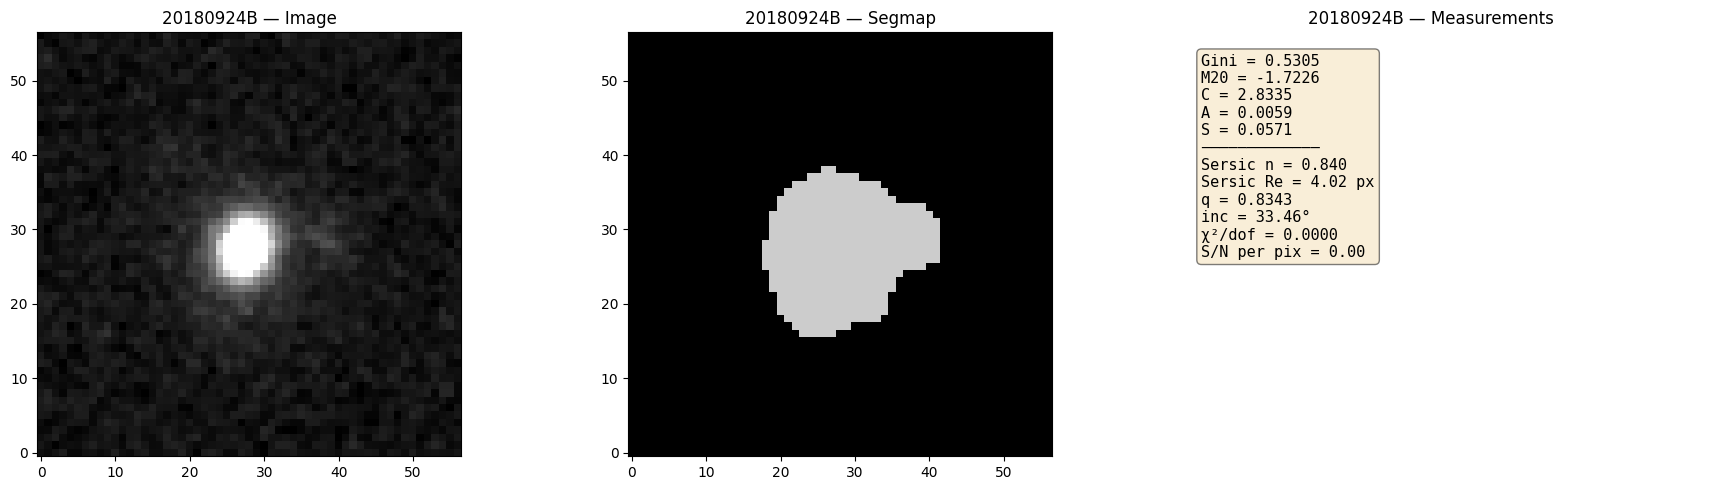


Processing 20190102C
  Image shape: (47, 47)
  Background: mean=0.000295, median=0.000220, std=0.002077
  Segmap: 1 sources, central label=1, central source pixels=189
  Non-parametric: Gini=0.3955, M20=-1.5404, C=2.1716, A=-0.1414, S=0.0198
  Sersic: n=0.5258, Re=5.04px, ellip=0.2881, q=0.7119, inc=44.61°, chi2/dof=0.0000


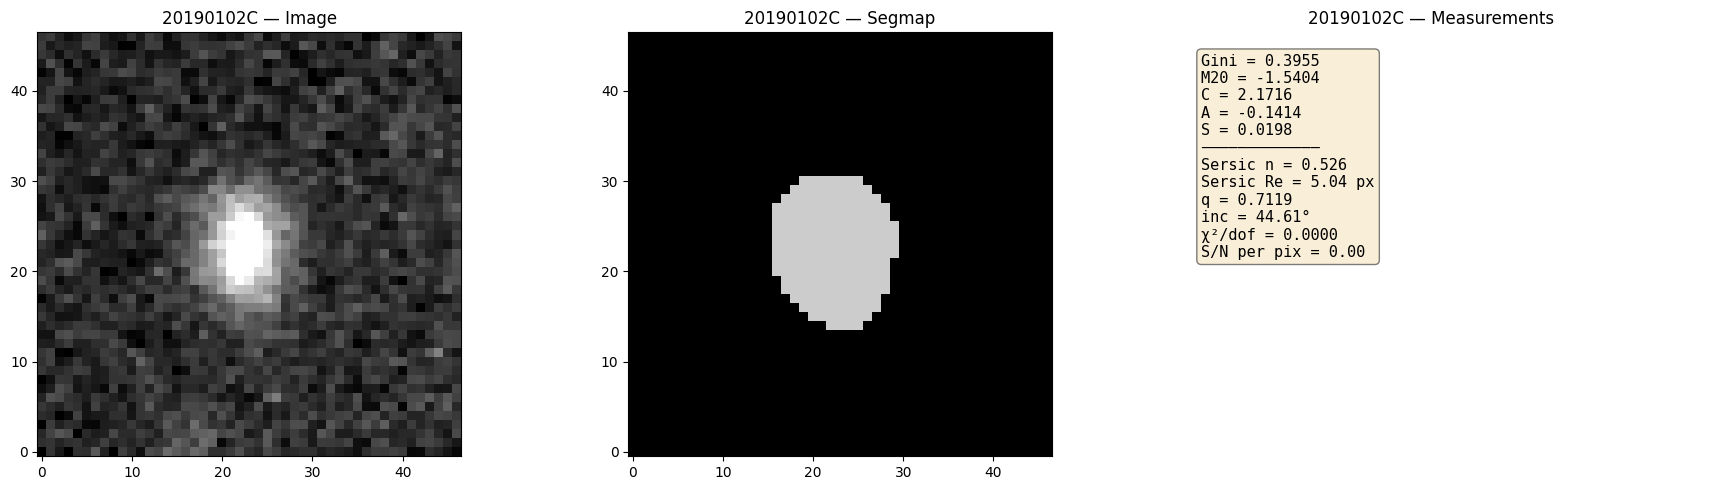


Processing 20190608B
  Image shape: (78, 82)
  Background: mean=0.003177, median=0.002587, std=0.005525
  Segmap: 1 sources, central label=1, central source pixels=1217
  Non-parametric: Gini=0.5445, M20=-1.8420, C=2.9930, A=0.0146, S=-0.0025
  Sersic: n=0.9651, Re=6.52px, ellip=0.1919, q=0.8081, inc=36.09°, chi2/dof=0.0000


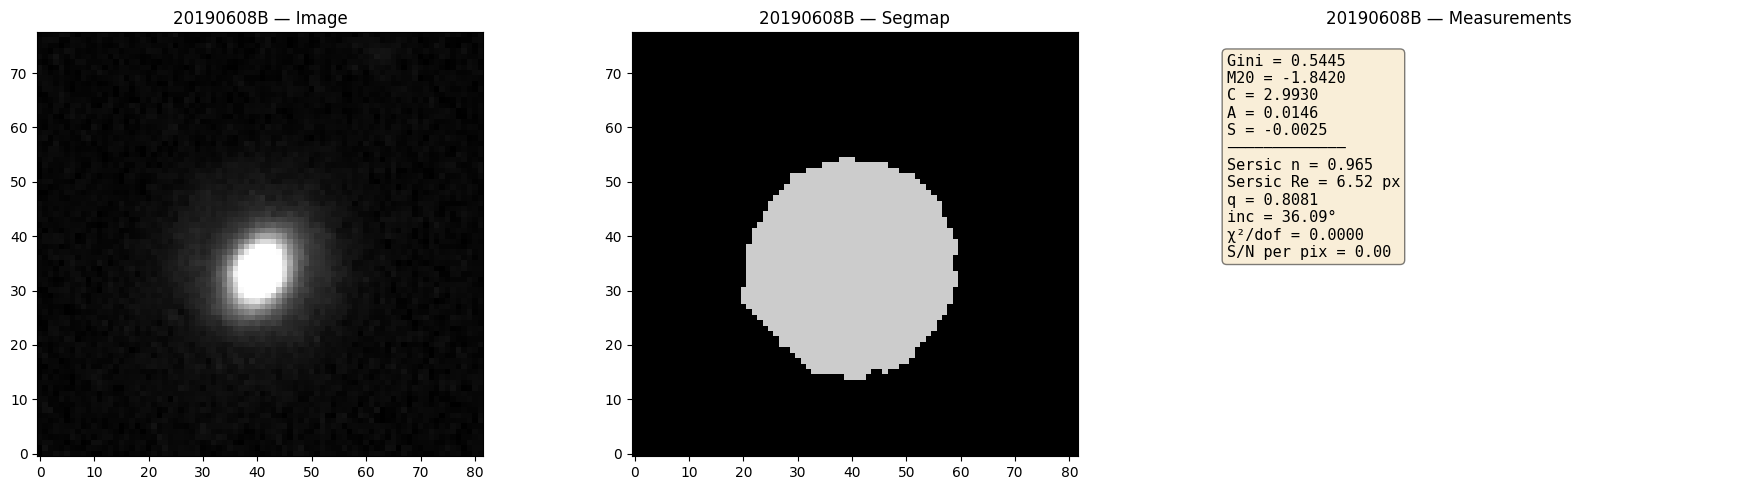


Processing 20190714A
  Image shape: (35, 35)
  Background: mean=0.001592, median=0.001237, std=0.006973
  Segmap: 1 sources, central label=1, central source pixels=177
  Non-parametric: Gini=0.4233, M20=-1.4910, C=2.2862, A=0.0028, S=0.0000
  Sersic: n=0.5174, Re=4.56px, ellip=0.4058, q=0.5942, inc=53.54°, chi2/dof=0.0000


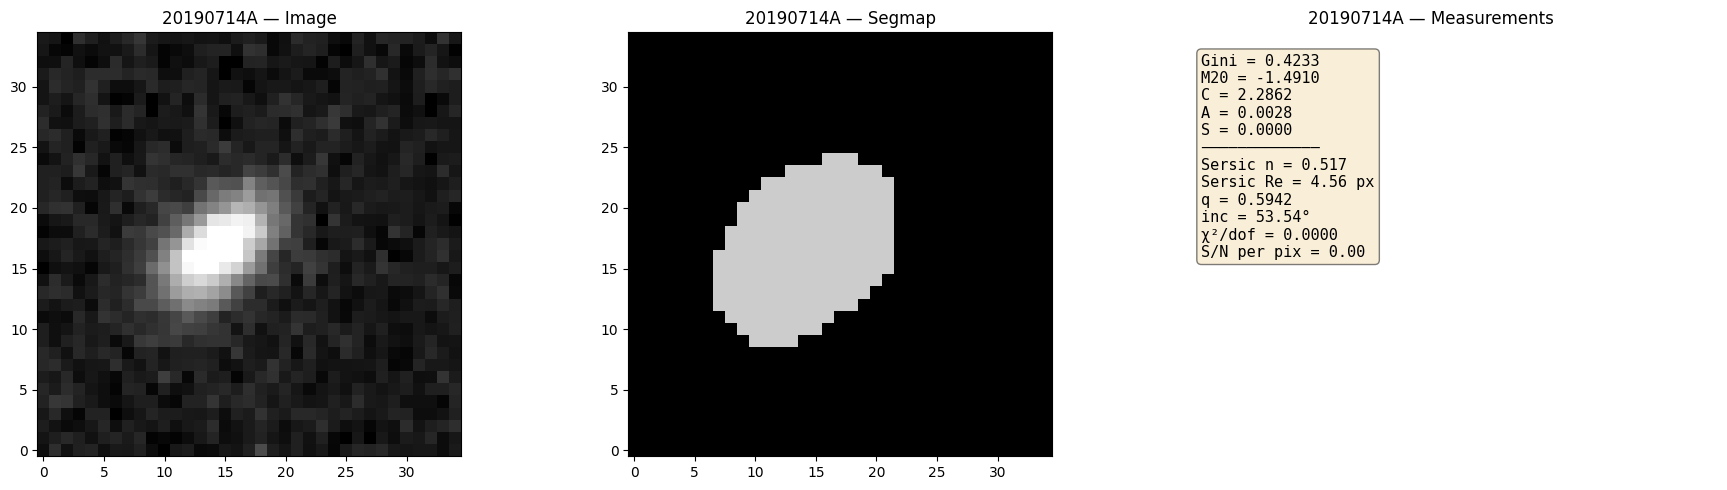


Processing 20191001A
  Image shape: (43, 41)
  Background: mean=0.002582, median=0.001603, std=0.004549
  Segmap: 1 sources, central label=1, central source pixels=507
  Non-parametric: Gini=0.4288, M20=-1.5359, C=2.2354, A=0.1352, S=0.0414
  Sersic: n=0.5596, Re=6.65px, ellip=0.3874, q=0.6126, inc=52.22°, chi2/dof=0.0000


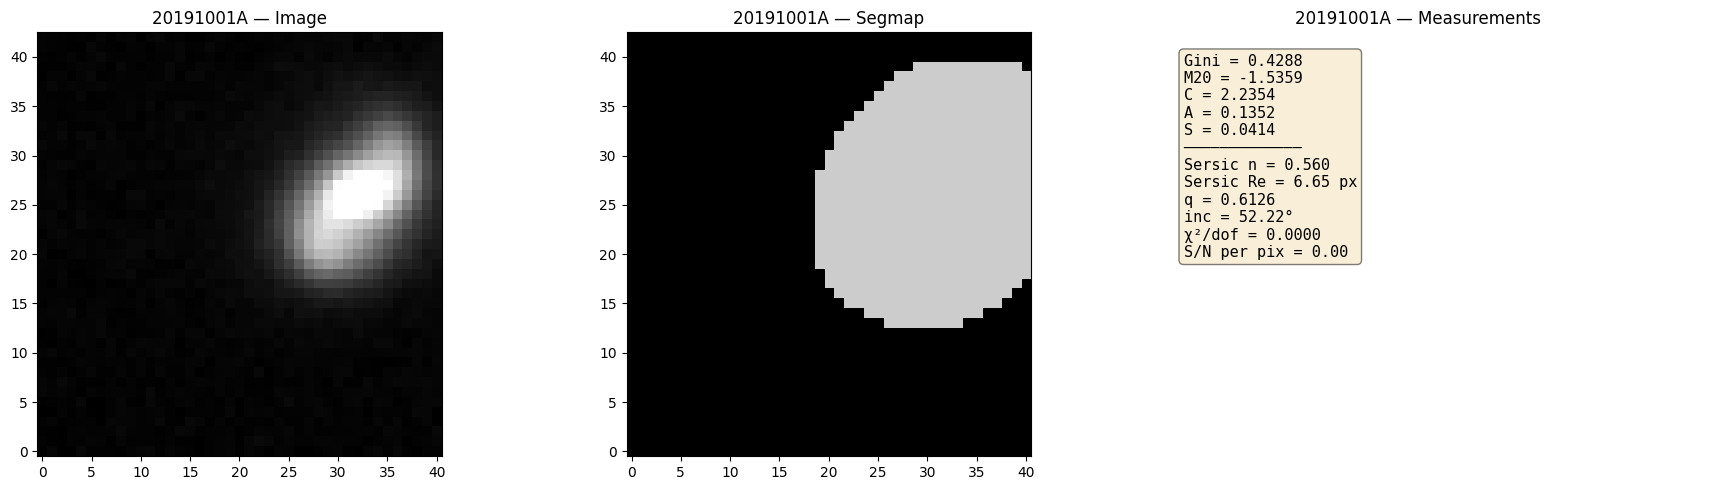


Processing 20200906A
  Image shape: (81, 81)
  Background: mean=0.000312, median=0.000278, std=0.002499
  Segmap: 1 sources, central label=1, central source pixels=362
  Non-parametric: Gini=0.4293, M20=-1.4378, C=2.4832, A=0.1459, S=0.0746
  Sersic: n=0.6026, Re=6.60px, ellip=0.5109, q=0.4891, inc=60.72°, chi2/dof=0.0000


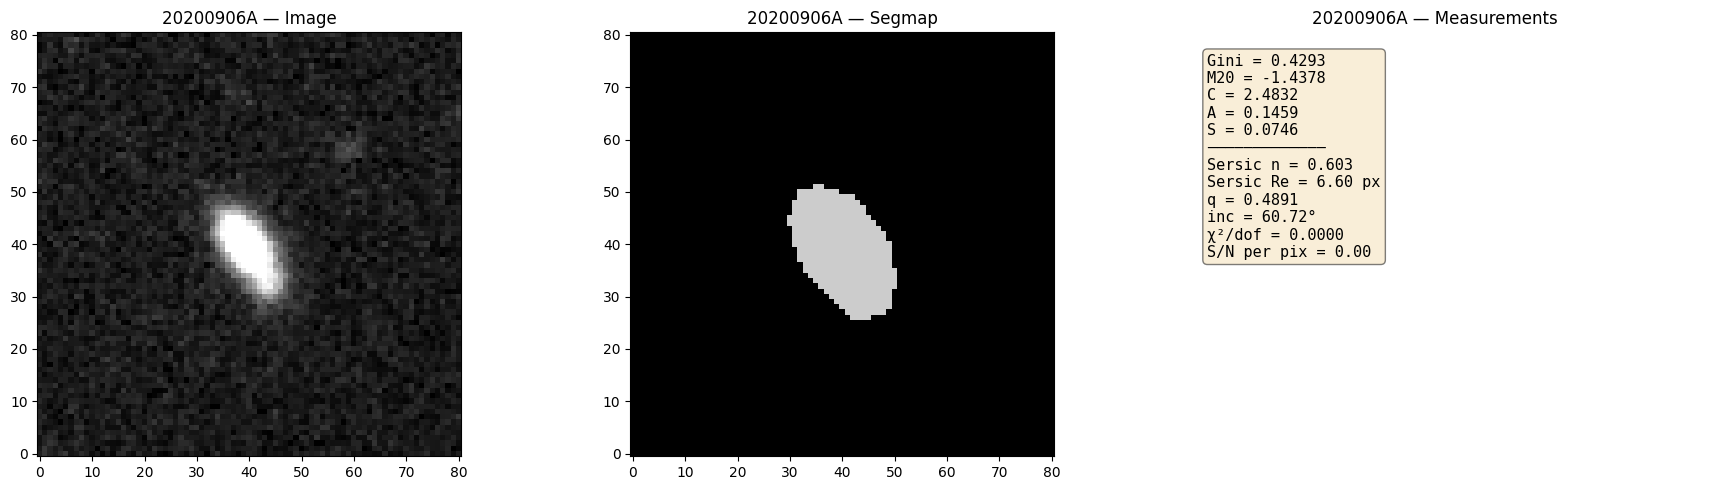


Processing 20210320C
  Image shape: (51, 51)
  Background: mean=0.001606, median=0.001327, std=0.008336
  Segmap: 1 sources, central label=1, central source pixels=213
  Non-parametric: Gini=0.4411, M20=-1.6935, C=2.4394, A=-0.0378, S=0.0425
  Sersic: n=0.6833, Re=4.29px, ellip=0.1689, q=0.8311, inc=33.79°, chi2/dof=0.0000


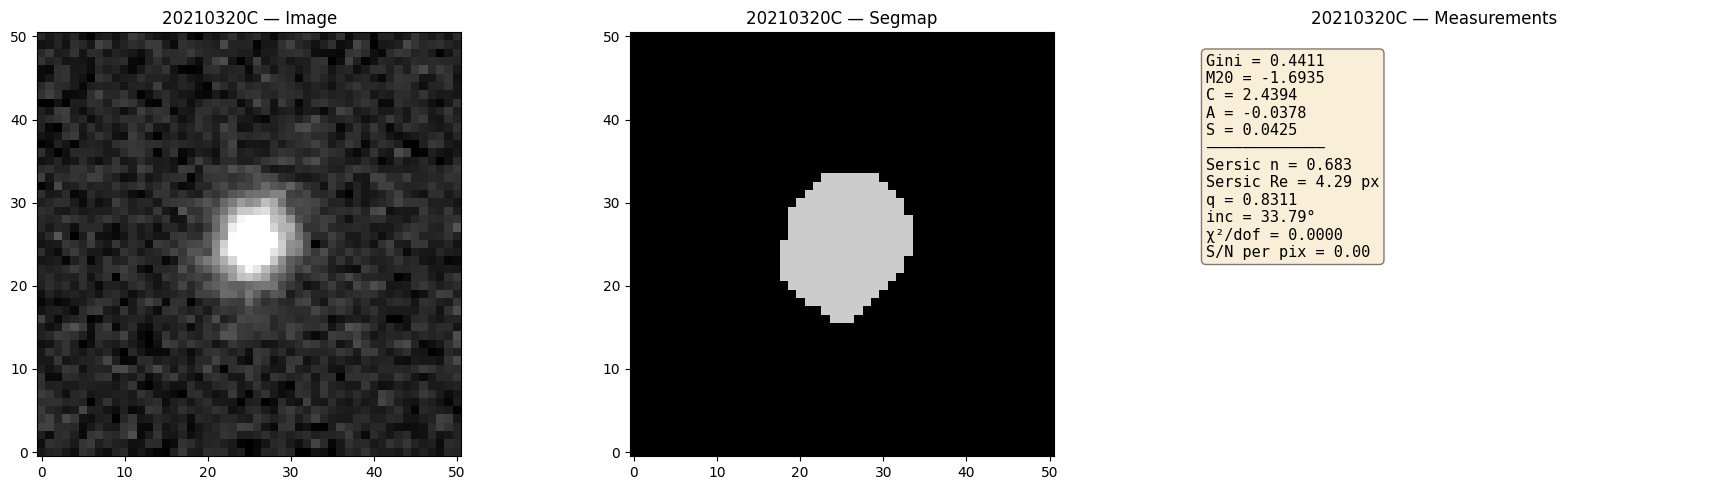


Processing 20210410D
  Image shape: (31, 25)
  Background: mean=0.002202, median=0.001792, std=0.002842
  No source at center pixel, using nearest label=1 (dist=6.4px)
  Segmap: 1 sources, central label=1, central source pixels=134
  Non-parametric: Gini=0.4729, M20=-1.5974, C=2.3055, A=-0.0881, S=0.0000
  Sersic: n=0.6109, Re=4.26px, ellip=0.2398, q=0.7602, inc=40.52°, chi2/dof=0.0000


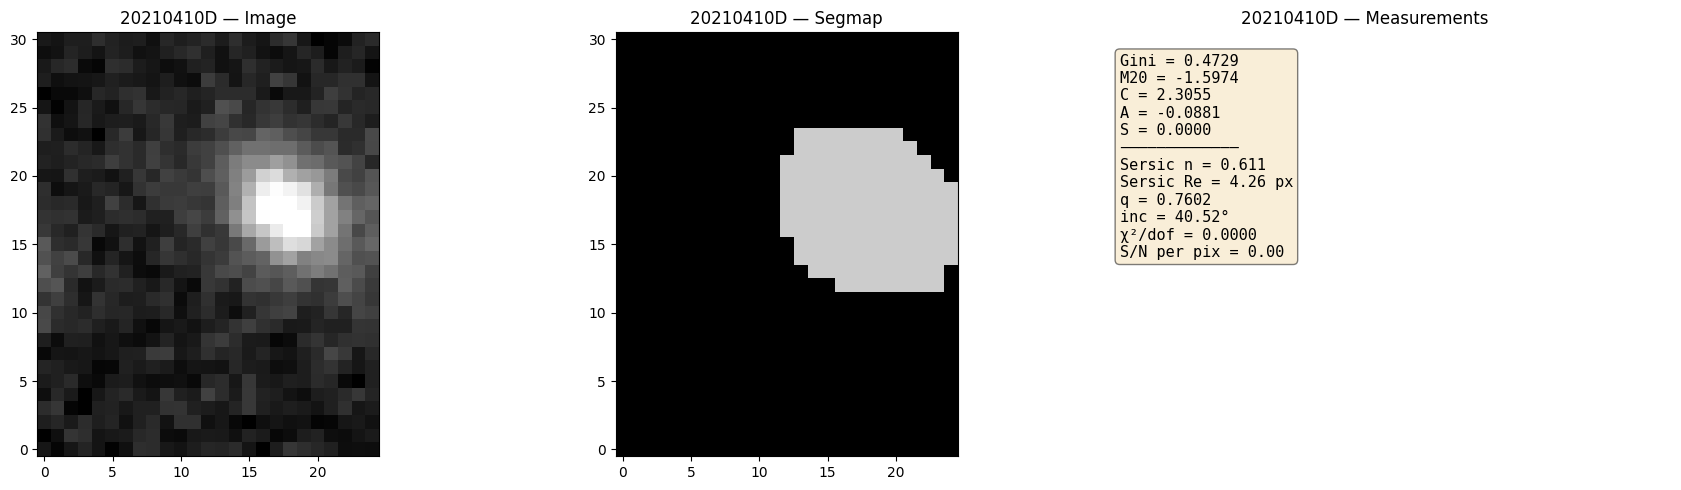


Processing 20210807D
  Image shape: (61, 66)
  Background: mean=196.969548, median=163.262024, std=216.310771
  Segmap: 1 sources, central label=1, central source pixels=622
  Non-parametric: Gini=0.4674, M20=-1.8019, C=2.5534, A=-0.2103, S=0.0121
  Sersic: n=0.9992, Re=11.37px, ellip=0.2871, q=0.7129, inc=44.53°, chi2/dof=51668694617689.1797


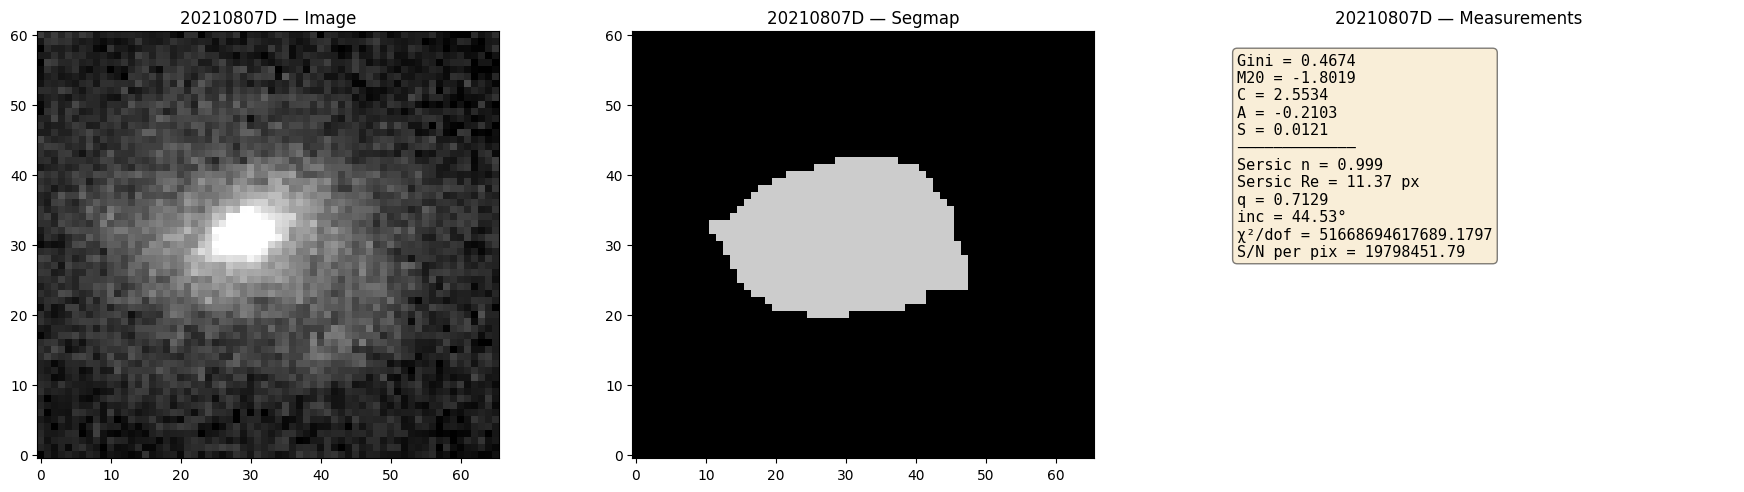


Processing 20211127I
  Image shape: (102, 116)
  Background: mean=465.438555, median=412.277588, std=362.349936
  Segmap: 1 sources, central label=1, central source pixels=1777


  Non-parametric: Gini=0.5207, M20=-1.9383, C=2.6919, A=-0.2623, S=-0.0424
  Sersic: n=1.1717, Re=16.25px, ellip=0.0675, q=0.9325, inc=21.17°, chi2/dof=1185375397866886.5000


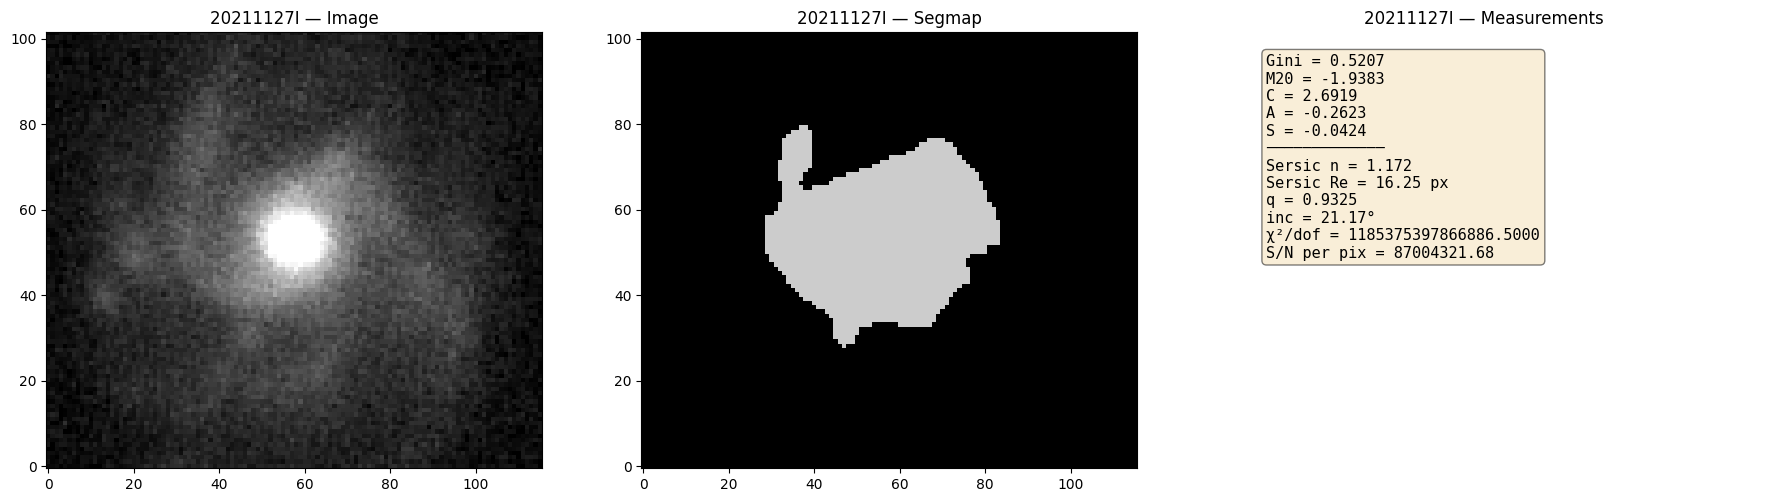


Processing 20211203C
  Image shape: (46, 46)
  Background: mean=0.000451, median=0.000337, std=0.004305
  Segmap: 1 sources, central label=1, central source pixels=68
  Non-parametric: Gini=0.4682, M20=-1.8114, C=2.7241, A=-0.1948, S=0.0000
  Sersic: n=0.8651, Re=4.01px, ellip=0.2906, q=0.7094, inc=44.81°, chi2/dof=0.0000


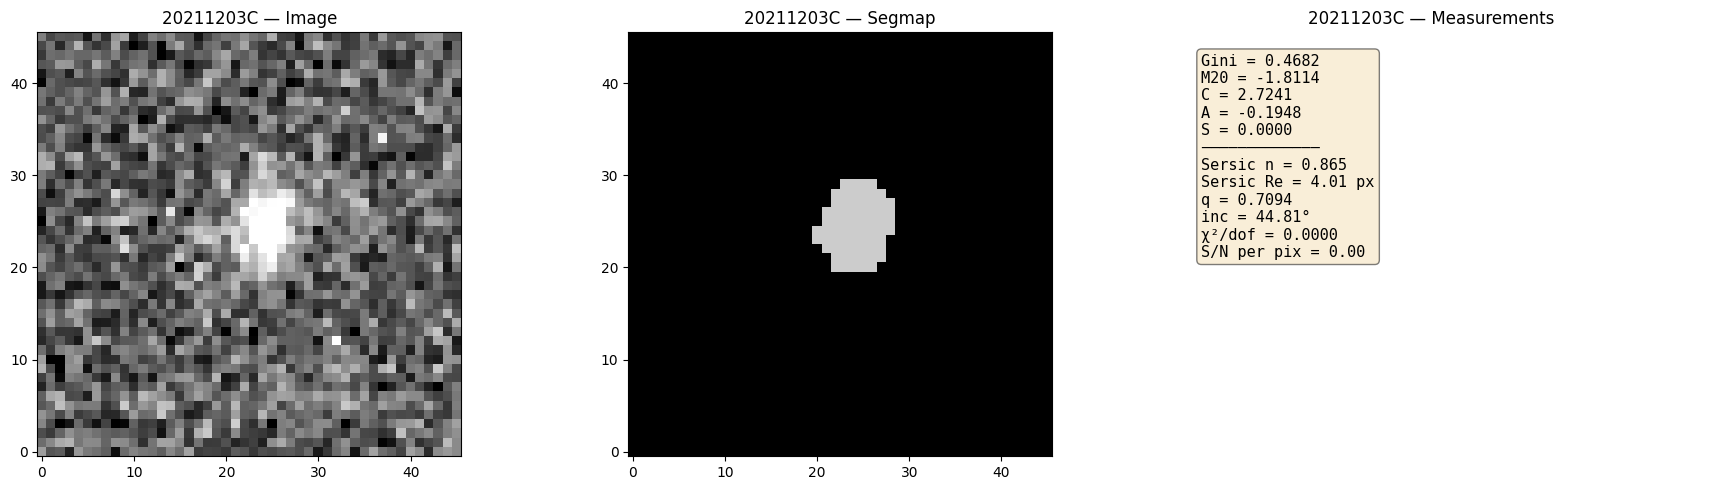


Processing 20211212A
  Image shape: (65, 65)
  Background: mean=0.016209, median=0.007347, std=0.022121
  Segmap: 1 sources, central label=1, central source pixels=1307


  Non-parametric: Gini=0.4064, M20=-1.6876, C=2.4660, A=0.1659, S=0.0036
  Sersic: n=0.9091, Re=11.76px, ellip=0.1588, q=0.8412, inc=32.73°, chi2/dof=0.0000


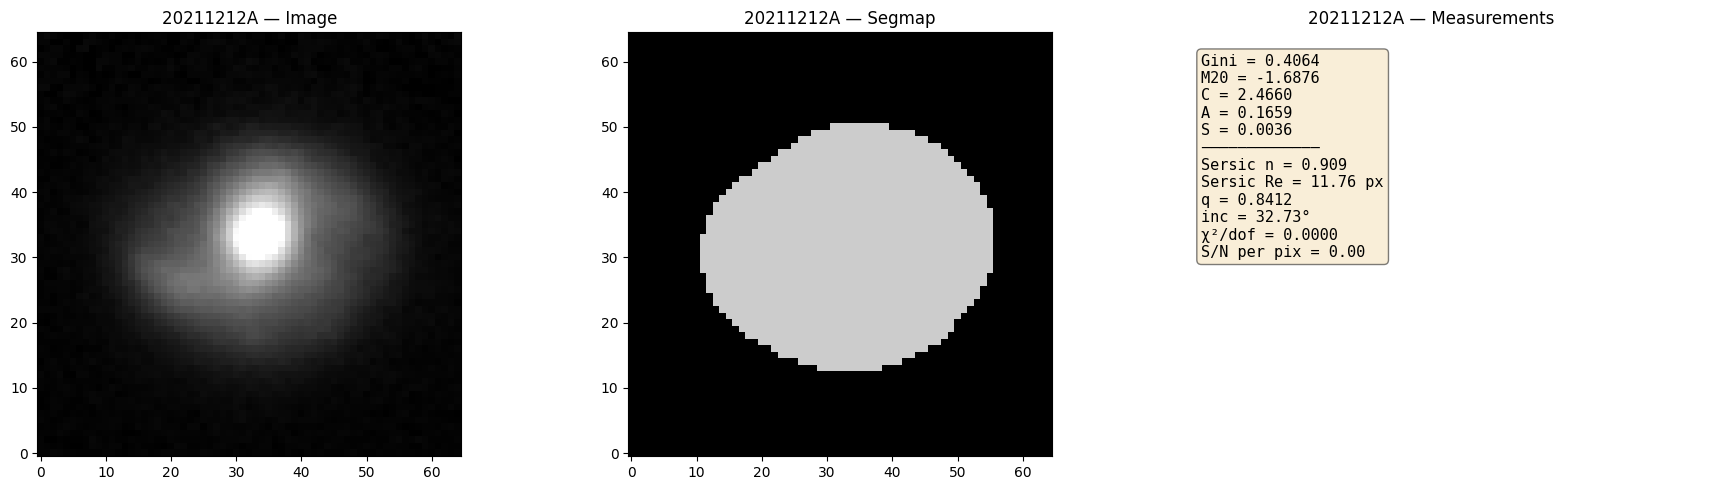


Processing 20220207C
  Image shape: (81, 91)
  Background: mean=49.999191, median=37.650944, std=145.333438
  Segmap: 1 sources, central label=1, central source pixels=786
  Non-parametric: Gini=0.4162, M20=-1.3248, C=2.4021, A=-0.1251, S=0.0090
  Sersic: n=0.4329, Re=22.38px, ellip=0.7373, q=0.2627, inc=74.77°, chi2/dof=6694343151078.3633


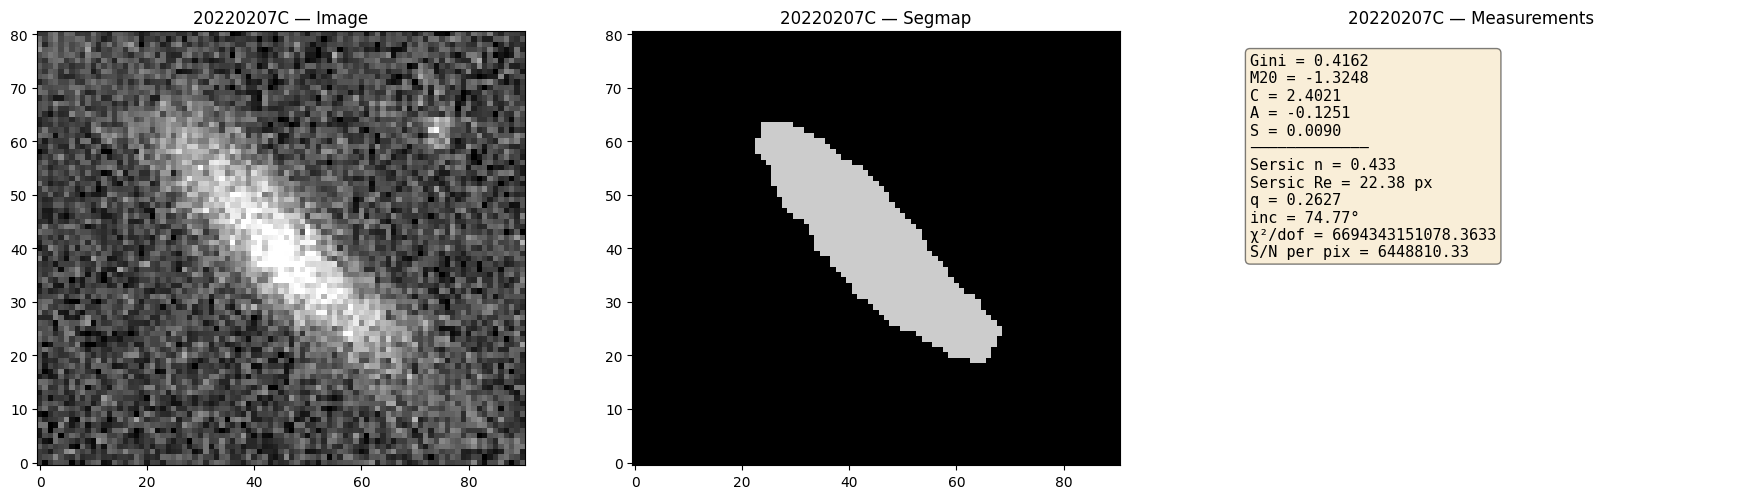


Processing 20220307B
  Image shape: (39, 47)
  Background: mean=29.713391, median=21.388203, std=126.945986
  Segmap: 1 sources, central label=1, central source pixels=169
  Non-parametric: Gini=0.3790, M20=-1.4100, C=2.1823, A=-0.2014, S=-0.0127
  Sersic: n=0.4990, Re=6.13px, ellip=0.2687, q=0.7313, inc=43.01°, chi2/dof=3249960570394.4873


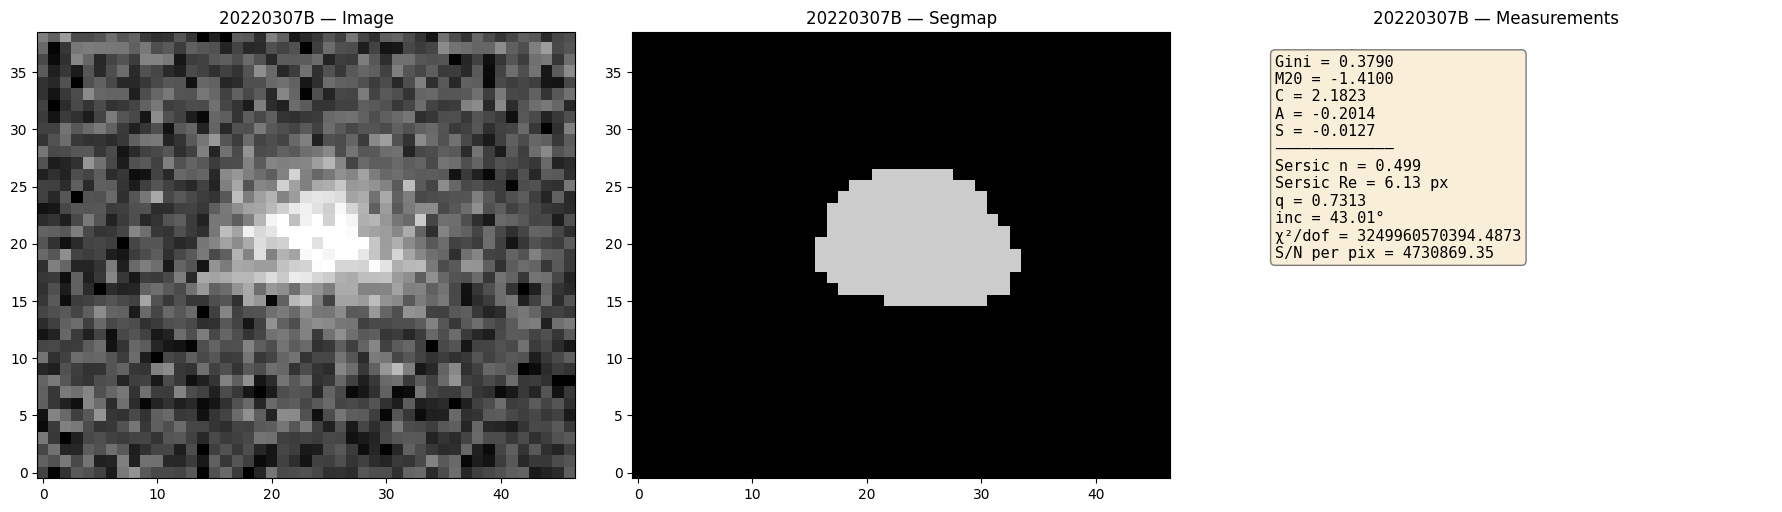


Processing 20220310F
  Image shape: (101, 101)
  Background: mean=0.000153, median=0.000132, std=0.003012
  Segmap: 1 sources, central label=1, central source pixels=270
  Non-parametric: Gini=0.4296, M20=-1.6577, C=2.4930, A=-0.0388, S=0.0337
  Sersic: n=0.7831, Re=5.75px, ellip=0.1873, q=0.8127, inc=35.64°, chi2/dof=0.0000


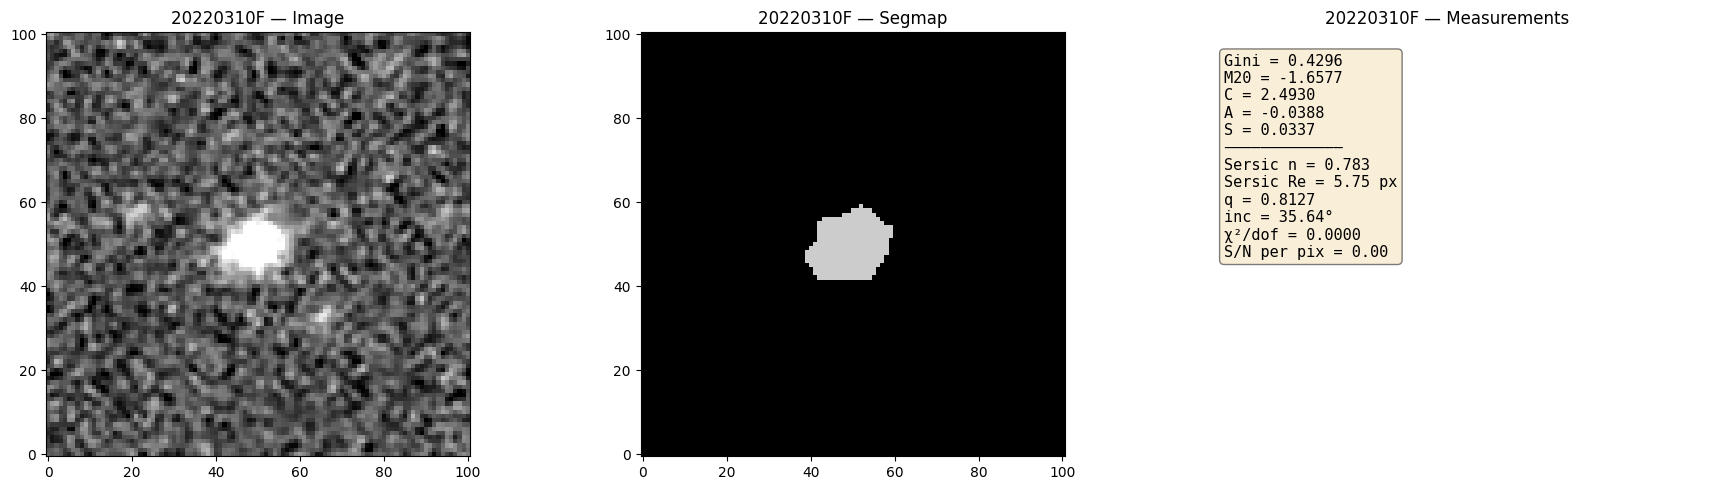


Processing 20220319D
  Image shape: (145, 146)
  Background: mean=196.119107, median=184.776215, std=144.761939
  Segmap: 1 sources, central label=1, central source pixels=1895
  Non-parametric: Gini=0.5812, M20=-2.4140, C=3.9469, A=-0.0851, S=-0.0158
  Sersic: n=2.0544, Re=13.03px, ellip=0.1143, q=0.8857, inc=27.66°, chi2/dof=8375686634253.2354


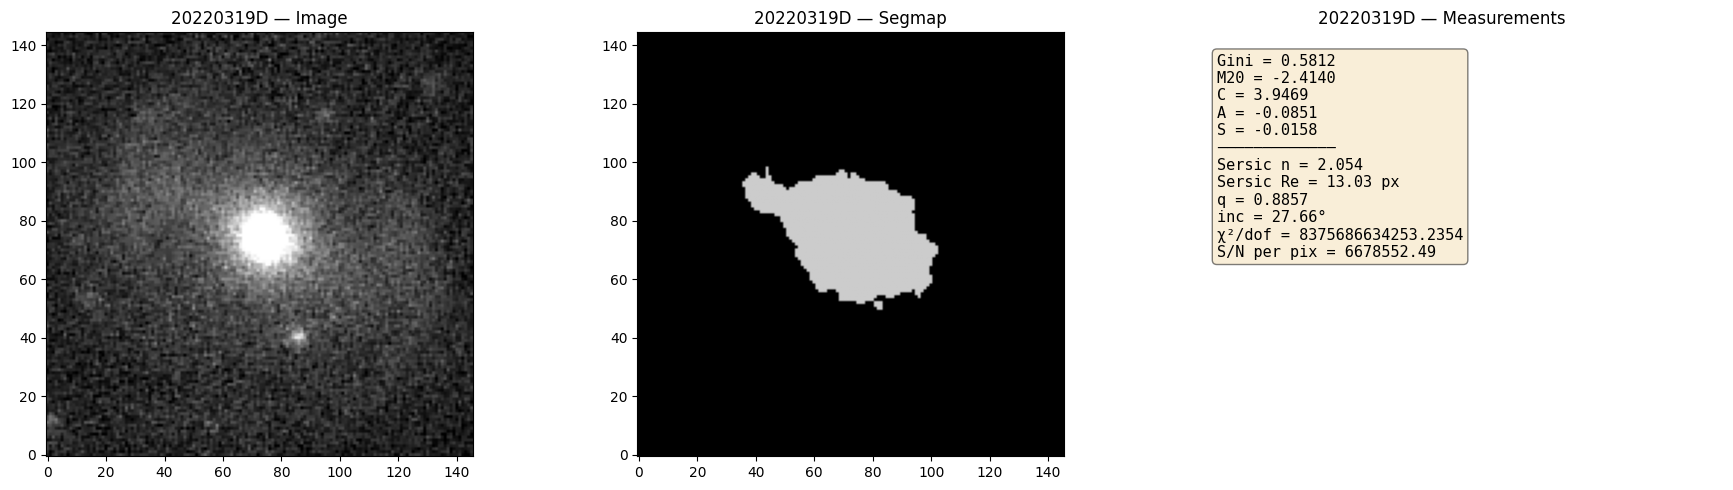


Processing 20220509G
  Image shape: (69, 121)
  Background: mean=0.006992, median=0.003674, std=0.009482
  Segmap: 1 sources, central label=1, central source pixels=2274
  Non-parametric: Gini=0.5376, M20=-1.0219, C=1.8233, A=0.5962, S=0.0532
  Sersic: n=1.4448, Re=8.78px, ellip=0.2517, q=0.7483, inc=41.56°, chi2/dof=0.0000


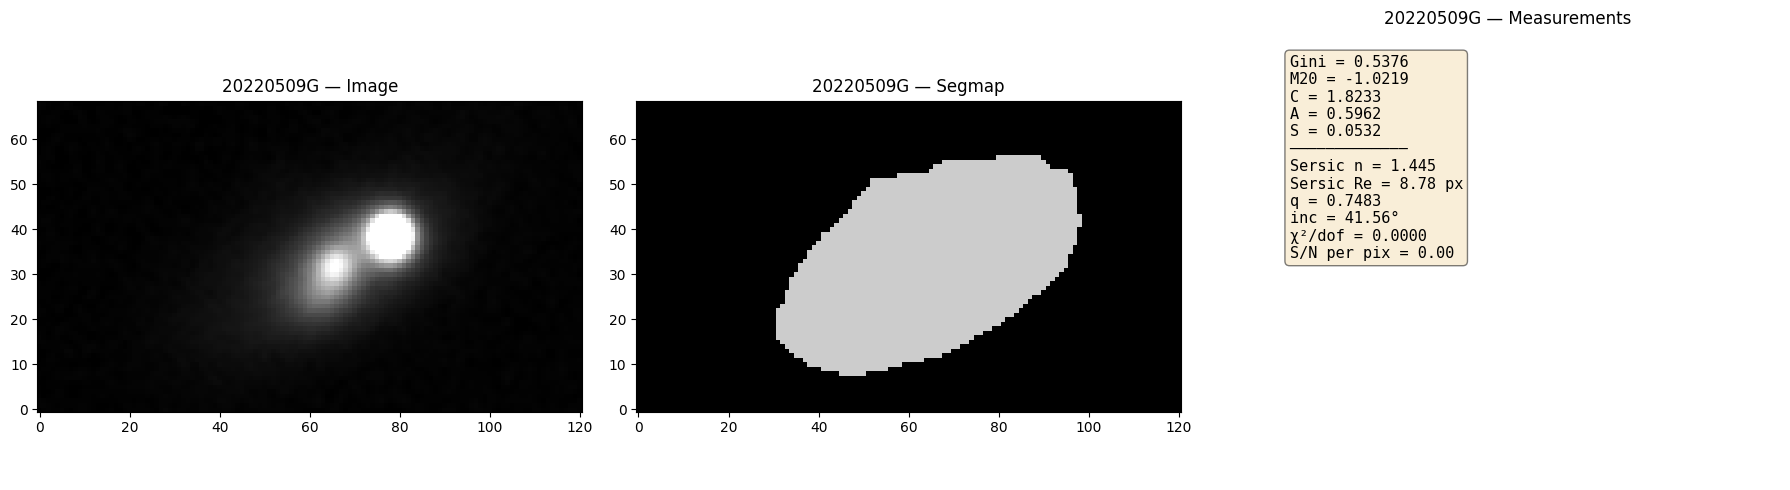


Processing 20220825A
  Image shape: (81, 81)
  Background: mean=13.193133, median=10.682448, std=136.770823
  Segmap: 1 sources, central label=1, central source pixels=120
  Non-parametric: Gini=0.4262, M20=-1.1567, C=2.3278, A=-0.1137, S=0.0570
  Sersic: n=0.6030, Re=6.50px, ellip=0.2815, q=0.7185, inc=44.07°, chi2/dof=6818604973317.1504


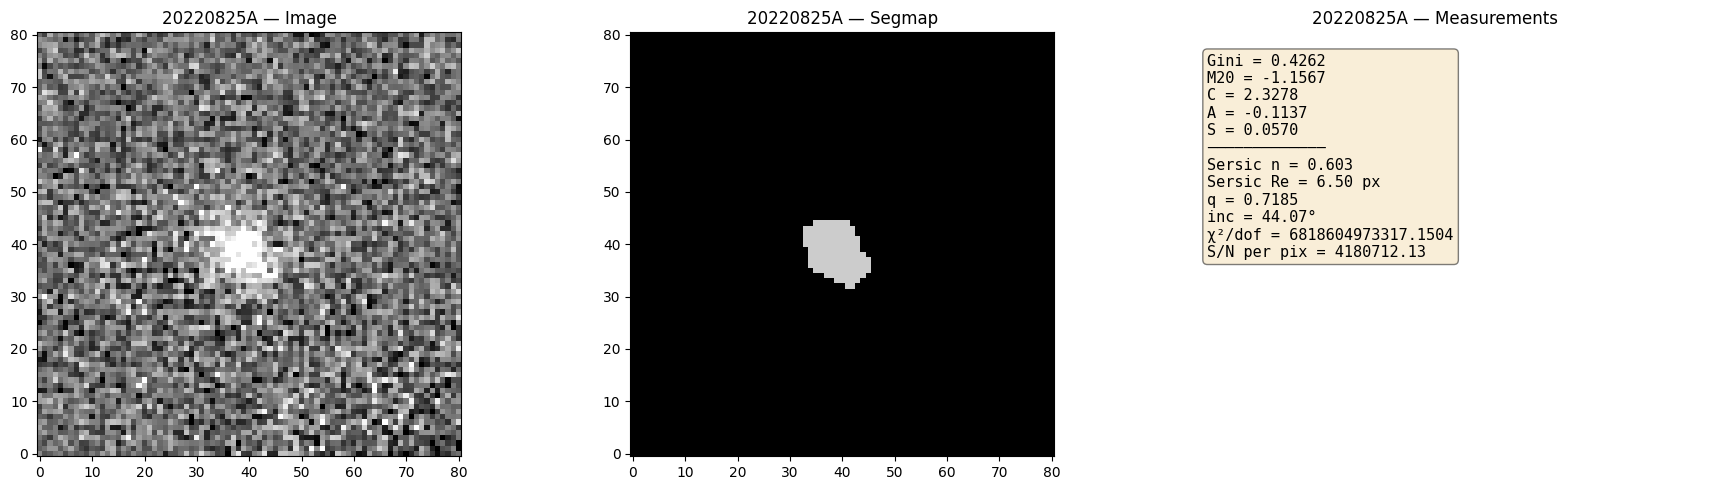


Processing 20220912A
  Image shape: (41, 47)
  Background: mean=18.675196, median=8.361897, std=154.887598
  Segmap: 1 sources, central label=1, central source pixels=167
  Non-parametric: Gini=0.4446, M20=-1.5798, C=2.2085, A=-0.1472, S=0.0302
  Sersic: n=0.6079, Re=5.69px, ellip=0.2577, q=0.7423, inc=42.07°, chi2/dof=11277119474583.8477


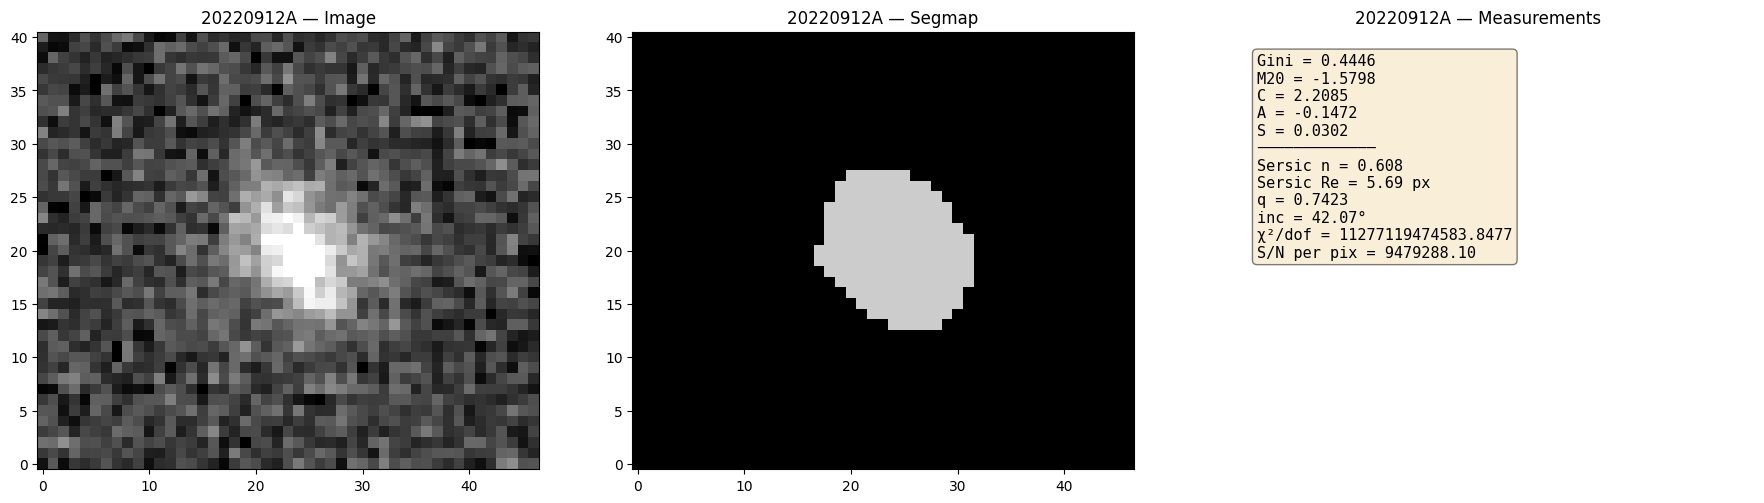


Processing 20220914A
  Image shape: (37, 37)
  Background: mean=0.004274, median=0.003460, std=0.004415
  Segmap: 1 sources, central label=1, central source pixels=345


  Non-parametric: Gini=0.4293, M20=-1.6127, C=2.2859, A=0.0144, S=0.0369
  Sersic: n=0.6071, Re=5.51px, ellip=0.1957, q=0.8043, inc=36.46°, chi2/dof=0.0000


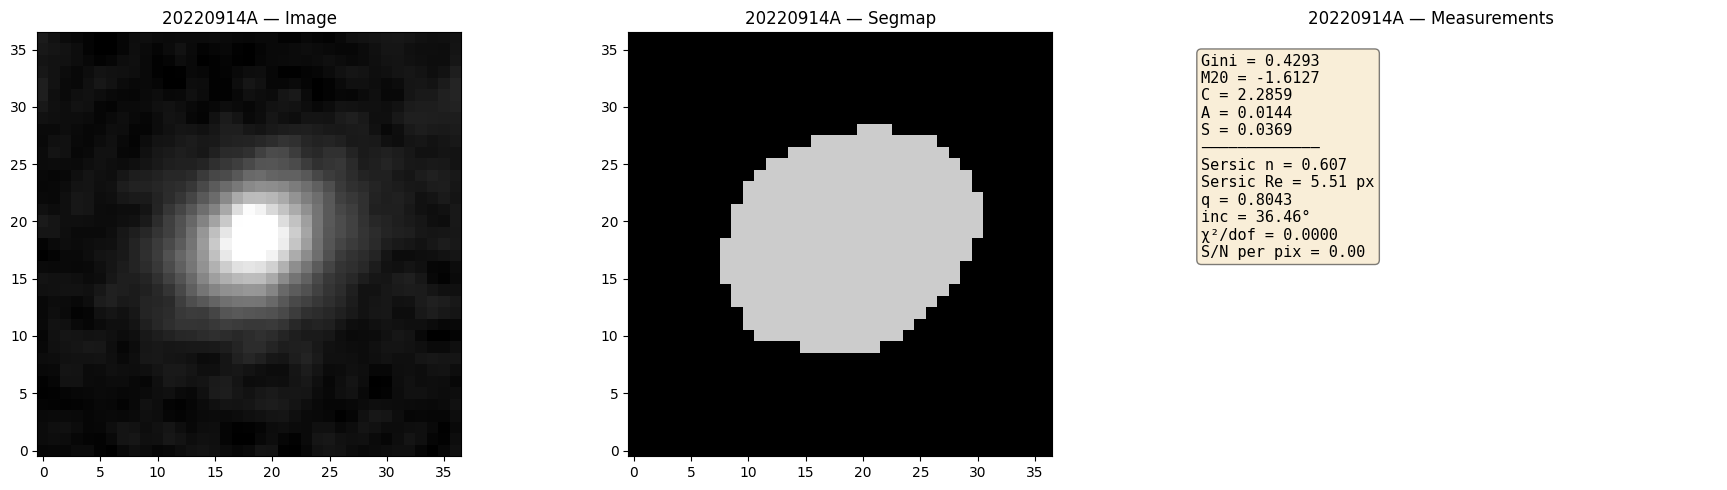


Processing 20220920A
  Image shape: (66, 66)
  Background: mean=0.003512, median=0.002680, std=0.005269
  Segmap: 1 sources, central label=1, central source pixels=983
  Non-parametric: Gini=0.4665, M20=-1.6951, C=2.4477, A=0.0119, S=-0.0016
  Sersic: n=0.7095, Re=7.63px, ellip=0.1004, q=0.8996, inc=25.89°, chi2/dof=0.0000


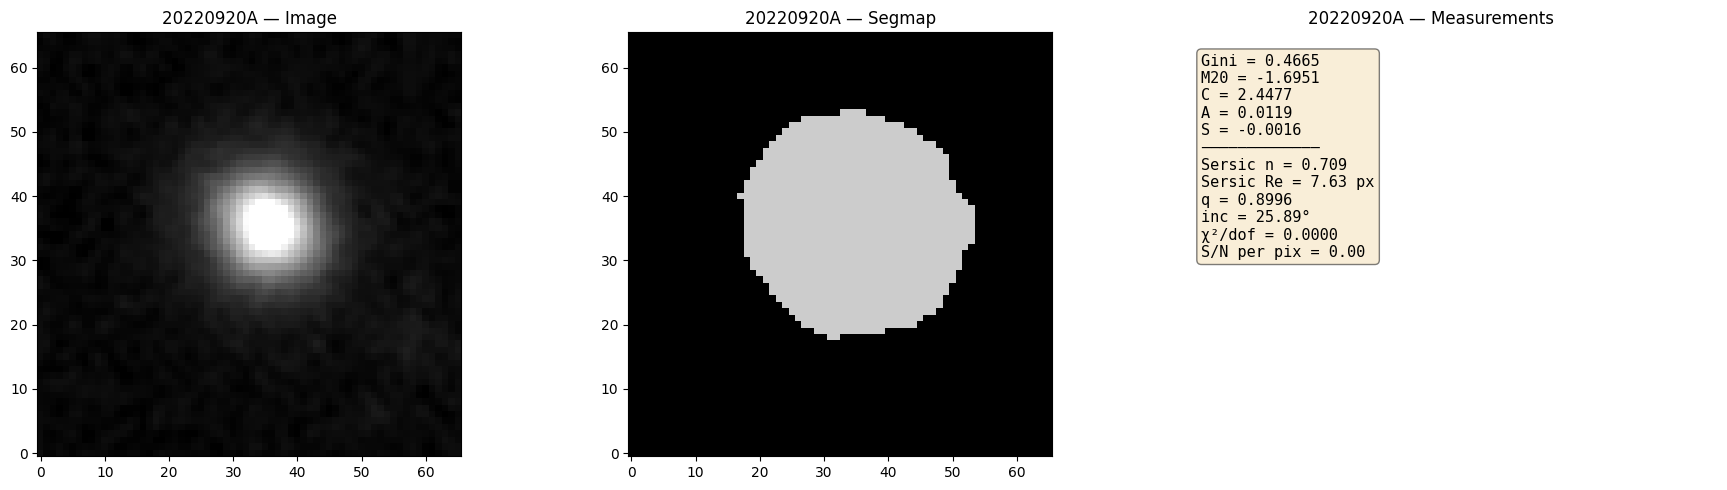


Processing 20221012A
  Image shape: (81, 81)
  Background: mean=0.000661, median=0.000564, std=0.003016
  Segmap: 1 sources, central label=1, central source pixels=694
  Non-parametric: Gini=0.4639, M20=-1.6949, C=2.5546, A=-0.0009, S=-0.0022
  Sersic: n=0.7464, Re=6.49px, ellip=0.2765, q=0.7235, inc=43.66°, chi2/dof=0.0000


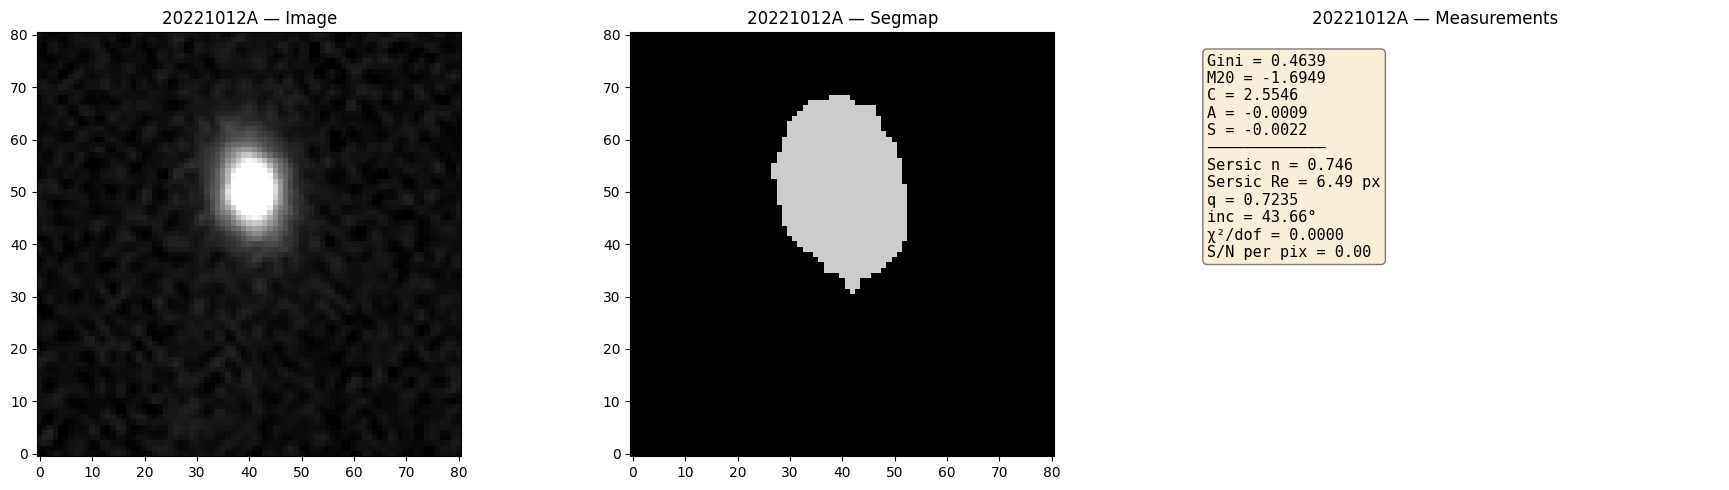


Done! Processed 23 galaxies.


In [7]:
# === Run statmorph on all FRB host galaxies ===

results = []

for frb_name in frb_names:
    print(f"\n{'='*60}")
    print(f"Processing {frb_name}")
    print(f"{'='*60}")

    # ---- Load the cropped galaxy image ----
    file_path = os.path.join(galaxy_dir, f"{frb_name}_flux.fits")
    with fits.open(file_path) as hdu:
        image = np.array(hdu[0].data, dtype=np.float64)

    # Replace NaNs with 0 for statmorph
    nan_mask = np.isnan(image)
    if np.any(nan_mask):
        image[nan_mask] = 0.0

    ny, nx = image.shape
    print(f"  Image shape: {image.shape}")

    # ---- Estimate background and noise ----
    from astropy.stats import sigma_clipped_stats
    mean_bg, median_bg, std_bg = sigma_clipped_stats(image, sigma=3.0)
    print(f"  Background: mean={mean_bg:.6f}, median={median_bg:.6f}, std={std_bg:.6f}")

    # Subtract background
    image_sub = image - median_bg

    # ---- Create segmentation map ----
    kernel = Gaussian2DKernel(x_stddev=1.5)
    convolved = convolve(image_sub, kernel)

    npixels = max(5, int(0.01 * nx * ny))
    threshold = 1.5 * std_bg
    segmap = detect_sources(convolved, threshold, npixels=npixels)

    if segmap is None:
        print(f"  WARNING: No sources detected, trying lower threshold")
        threshold = 1.0 * std_bg
        segmap = detect_sources(convolved, threshold, npixels=max(3, npixels // 2))

    if segmap is None:
        print(f"  SKIP: No sources detected at all")
        continue

    segmap_array = segmap.data

    # The central source should be labeled — find the label at the image center
    cy, cx = ny // 2, nx // 2
    center_label = segmap_array[cy, cx]

    if center_label == 0:
        labels = np.unique(segmap_array)
        labels = labels[labels > 0]
        if len(labels) == 0:
            print(f"  SKIP: No labeled sources")
            continue
        best_label = labels[0]
        best_dist = np.inf
        for lab in labels:
            ys, xs = np.where(segmap_array == lab)
            dist = np.sqrt((np.mean(ys) - cy)**2 + (np.mean(xs) - cx)**2)
            if dist < best_dist:
                best_dist = dist
                best_label = lab
        center_label = best_label
        print(f"  No source at center pixel, using nearest label={center_label} (dist={best_dist:.1f}px)")

    segmap_central = np.where(segmap_array == center_label, center_label, 0).astype(np.int32)

    print(f"  Segmap: {len(np.unique(segmap_array)) - 1} sources, central label={center_label}, "
          f"central source pixels={np.sum(segmap_central > 0)}")

    # ---- Weightmap (uniform for now — will use invvar later) ----
    gain = 1.0 / (std_bg**2) if std_bg > 0 else 1e4
    weightmap = np.ones_like(image_sub) * gain

    # ---- Run statmorph ----
    try:
        source_morphs = statmorph.source_morphology(
            image_sub, segmap_central, weightmap=weightmap
        )
        morph = source_morphs[0]
    except Exception as e:
        print(f"  ERROR in statmorph: {e}")
        continue

    # ---- Extract results ----
    gini = morph.gini
    m20 = morph.m20
    C = morph.concentration
    A = morph.asymmetry
    S = morph.smoothness

    sersic_n = morph.sersic_n
    sersic_re = morph.sersic_rhalf
    sersic_ellip = morph.sersic_ellip
    sersic_theta = morph.sersic_theta
    q_statmorph = 1.0 - sersic_ellip
    inc_statmorph = np.degrees(np.arccos(q_statmorph)) if 0 <= q_statmorph <= 1 else np.nan
    sersic_chi2 = morph.sersic_chi2_dof

    print(f"  Non-parametric: Gini={gini:.4f}, M20={m20:.4f}, C={C:.4f}, A={A:.4f}, S={S:.4f}")
    print(f"  Sersic: n={sersic_n:.4f}, Re={sersic_re:.2f}px, ellip={sersic_ellip:.4f}, "
          f"q={q_statmorph:.4f}, inc={inc_statmorph:.2f}°, chi2/dof={sersic_chi2:.4f}")

    results.append({
        'frb_name': frb_name,
        'gini': gini,
        'm20': m20,
        'concentration': C,
        'asymmetry': A,
        'smoothness': S,
        'sersic_n': sersic_n,
        'sersic_re': sersic_re,
        'sersic_ellip': sersic_ellip,
        'sersic_q': q_statmorph,
        'sersic_inc': inc_statmorph,
        'sersic_theta_rad': sersic_theta,
        'sersic_chi2_dof': sersic_chi2,
        'rpetro': morph.rpetro_circ,
        'r20': morph.r20,
        'r80': morph.r80,
        'sn_per_pixel': morph.sn_per_pixel,
        'gini_m20_merger': morph.gini_m20_merger,
        'gini_m20_bulge': morph.gini_m20_bulge,
    })

    # ---- Plot ----
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    vmin = np.percentile(image_sub, 1)
    vmax = np.percentile(image_sub, 99)
    axes[0].imshow(image_sub, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
    axes[0].set_title(f"{frb_name} — Image")

    axes[1].imshow(segmap_central, origin='lower', cmap='nipy_spectral')
    axes[1].set_title(f"{frb_name} — Segmap")

    # Sersic fit summary text panel
    ax = axes[2]
    ax.axis('off')
    text = (
        f"Gini = {gini:.4f}\n"
        f"M20 = {m20:.4f}\n"
        f"C = {C:.4f}\n"
        f"A = {A:.4f}\n"
        f"S = {S:.4f}\n"
        f"─────────────\n"
        f"Sersic n = {sersic_n:.3f}\n"
        f"Sersic Re = {sersic_re:.2f} px\n"
        f"q = {q_statmorph:.4f}\n"
        f"inc = {inc_statmorph:.2f}°\n"
        f"χ²/dof = {sersic_chi2:.4f}\n"
        f"S/N per pix = {morph.sn_per_pixel:.2f}"
    )
    ax.text(0.1, 0.95, text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_title(f"{frb_name} — Measurements")

    plt.tight_layout()
    plt.show()

print(f"\nDone! Processed {len(results)} galaxies.")

In [ ]:
# Save statmorph results
df_sm = pd.DataFrame(results)
df_sm.to_csv('statmorph_results.csv', index=False)
print(f"Saved {len(df_sm)} rows to statmorph_results.csv")
df_sm

In [ ]:
# === Compare statmorph Sersic fits vs GALFIT ===

df_sm = pd.read_csv('statmorph_results.csv')
galfit = pd.read_csv('galfit_inc_angle.csv')

merged = df_sm.merge(galfit, on='frb_name', how='inner')
print(f"Merged: {len(merged)} galaxies")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Inclination angle comparison ---
ax = axes[0]
ax.scatter(merged['inc_psf'], merged['sersic_inc'], c='steelblue', s=50, edgecolors='k', alpha=0.8)
lims = [0, 90]
ax.plot(lims, lims, 'k--', alpha=0.5, label='1:1')
ax.set_xlabel('GALFIT Inclination (with PSF) [deg]')
ax.set_ylabel('Statmorph Sersic Inclination [deg]')
ax.set_title('Inclination Angle Comparison')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend()
for _, row in merged.iterrows():
    ax.annotate(row['frb_name'][-4:], (row['inc_psf'], row['sersic_inc']),
                fontsize=6, alpha=0.7)

# --- Axis ratio comparison ---
ax = axes[1]
ax.scatter(merged['b_a_psf'], merged['sersic_q'], c='darkorange', s=50, edgecolors='k', alpha=0.8)
lims = [0, 1]
ax.plot(lims, lims, 'k--', alpha=0.5, label='1:1')
ax.set_xlabel('GALFIT b/a (with PSF)')
ax.set_ylabel('Statmorph Sersic q = 1 - ellip')
ax.set_title('Axis Ratio Comparison')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend()

# --- Effective radius comparison ---
ax = axes[2]
ax.scatter(merged['re_psf'], merged['sersic_re'], c='forestgreen', s=50, edgecolors='k', alpha=0.8)
max_re = max(merged['re_psf'].max(), merged['sersic_re'].max()) * 1.1
ax.plot([0, max_re], [0, max_re], 'k--', alpha=0.5, label='1:1')
ax.set_xlabel('GALFIT Re (with PSF) [pix]')
ax.set_ylabel('Statmorph Sersic Re [pix]')
ax.set_title('Effective Radius Comparison')
ax.legend()

plt.tight_layout()
plt.savefig('plots_comparison/statmorph_vs_galfit.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nInclination angle difference (GALFIT_psf - Statmorph):")
diff_inc = merged['inc_psf'] - merged['sersic_inc']
print(f"  Mean: {diff_inc.mean():.2f} deg")
print(f"  Std:  {diff_inc.std():.2f} deg")
print(f"  Median: {diff_inc.median():.2f} deg")

print(f"\nAxis ratio difference (GALFIT_psf - Statmorph):")
diff_q = merged['b_a_psf'] - merged['sersic_q']
print(f"  Mean: {diff_q.mean():.4f}")
print(f"  Std:  {diff_q.std():.4f}")

In [ ]:
# === Non-parametric morphology summary ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gini vs M20 diagram
ax = axes[0]
ax.scatter(df_sm['m20'], df_sm['gini'], c='steelblue', s=60, edgecolors='k', alpha=0.8)
for _, row in df_sm.iterrows():
    ax.annotate(row['frb_name'][-4:], (row['m20'], row['gini']),
                fontsize=6, alpha=0.7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('M20')
ax.set_ylabel('Gini')
ax.set_title('Gini-M20 Diagram')
# Merger classification line (Lotz+ 2008)
m20_line = np.linspace(-3, 0, 100)
gini_line = -0.14 * m20_line + 0.33
ax.plot(m20_line, gini_line, 'r--', alpha=0.5, label='Merger line (Lotz+08)')
ax.legend(fontsize=8)

# CAS: Concentration vs Asymmetry
ax = axes[1]
sc = ax.scatter(df_sm['concentration'], df_sm['asymmetry'], c=df_sm['smoothness'],
                cmap='viridis', s=60, edgecolors='k', alpha=0.8)
plt.colorbar(sc, ax=ax, label='Smoothness')
for _, row in df_sm.iterrows():
    ax.annotate(row['frb_name'][-4:], (row['concentration'], row['asymmetry']),
                fontsize=6, alpha=0.7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Concentration (C)')
ax.set_ylabel('Asymmetry (A)')
ax.set_title('CAS Diagram')

plt.tight_layout()
plt.savefig('plots_comparison/statmorph_nonparametric.png', dpi=150, bbox_inches='tight')
plt.show()